In [180]:
import pandas as pd
import glob
import numpy as np
import datetime as dt
from matplotlib import pyplot as plt

In [ ]:
#testtt

In [250]:
#Extracting household power consumption files
files_hp = glob.glob(r'./p1-power-weather/household_power_consumption/*.csv')
df_list = []
for file in files_hp:
    df = pd.read_csv(file, sep = ';', header = None, low_memory=False)
    df_list.append(df)
df_hp = pd.concat(df_list, ignore_index = True)
#Renaming columns
column_names = ['date','time','g_active_p','g_reactive_p','voltage','g_intensity','sub_meter1','sub_meter2','sub_meter3']
df_hp.columns = column_names

#Changing data types to numeric
df_hp[column_names[2:]] = df_hp[column_names[2:]].apply(pd.to_numeric, errors = "coerce")

#Changing date column type to date
#df_hp['date']= pd.to_datetime(df_hp['date'])
#df_hp['date'] = df_hp['date'].apply(lambda x:x.date())
"""#Interpolating missing values
df_hp=df_hp.interpolate(method='linear',axis=1)"""

#Replacing nan with 0 (~25000 nan values)
df_hp = df_hp.replace(np.nan, 0)

#Changing time column type to time
df_hp['time']= pd.to_datetime(df_hp['time'], format = "%H:%M:%S").dt.strftime('%H:%M:%S')

In [251]:
df_hp['dt']=pd.to_datetime(df_hp['date'] + ' ' + df_hp['time'])

In [255]:
df_hp

,date,time,g_active_p,g_reactive_p,voltage,g_intensity,sub_meter1,sub_meter2,sub_meter3,dt
0,1/1/2010,00:00:00,1.790,0.236,240.65,7.4,0.0,0.0,18.0,2010-01-01 00:00:00
1,1/1/2010,00:01:00,1.780,0.234,240.07,7.4,0.0,0.0,18.0,2010-01-01 00:01:00
2,1/1/2010,00:02:00,1.780,0.234,240.15,7.4,0.0,0.0,19.0,2010-01-01 00:02:00
3,1/1/2010,00:03:00,1.746,0.186,240.26,7.2,0.0,0.0,18.0,2010-01-01 00:03:00
4,1/1/2010,00:04:00,1.686,0.102,240.12,7.0,0.0,0.0,18.0,2010-01-01 00:04:00
...,...,...,...,...,...,...,...,...,...,...
2053258,31/12/2008,23:55:00,0.484,0.064,247.69,2.2,0.0,0.0,0.0,2008-12-31 23:55:00
2053259,31/12/2008,23:56:00,0.482,0.064,247.35,2.2,0.0,0.0,0.0,2008-12-31 23:56:00
2053260,31/12/2008,23:57:00,0.482,0.064,246.99,2.2,0.0,0.0,0.0,2008-12-31 23:57:00
2053261,31/12/2008,23:58:00,0.480,0.064,246.52,2.2,0.0,0.0,0.0,2008-12-31 23:58:00


In [192]:
#
df_hpc = pd.DataFrame()
for i in range(2053262//180):
    df_hpc.append(df_hp[180*i:180*(i+1)].mean(axis=0))


In [253]:
#Resampling data 
df_hpc = df_hp.resample('180T', on='dt').mean()

In [273]:
df_hpc

,g_active_p,g_reactive_p,voltage,g_intensity,sub_meter1,sub_meter2,sub_meter3
dt,,,,,,,
2007-01-01 00:00:00,2.552122,0.097033,241.886000,10.504444,0.000000,0.305556,0.000000
2007-01-01 03:00:00,2.497878,0.093311,242.690167,10.220000,0.000000,0.283333,0.000000
2007-01-01 06:00:00,2.448244,0.090367,240.893056,10.090000,0.000000,0.200000,0.000000
2007-01-01 09:00:00,2.794622,0.083011,238.509500,11.650000,0.000000,0.194444,4.838889
2007-01-01 12:00:00,2.024222,0.143100,239.028056,8.527778,0.000000,0.266667,3.016667
...,...,...,...,...,...,...,...
2010-12-11 09:00:00,1.610544,0.081333,238.209111,6.740000,3.633333,0.311111,17.405556
2010-12-11 12:00:00,1.185900,0.127656,238.059722,5.075556,0.000000,0.211111,7.188889
2010-12-11 15:00:00,1.869511,0.190389,234.233278,8.155556,0.000000,0.577778,8.805556


In [279]:
df_hpc['date']= df_hpc.index

In [277]:
type(df_hpc.iloc[2,7])

pandas._libs.tslibs.timestamps.Timestamp

In [256]:
len(df_hpc)

11528

In [75]:
df_hp.dtypes

date            datetime64[ns]
time                    object
g_active_p             float64
g_reactive_p           float64
voltage                float64
g_intensity            float64
sub_meter1             float64
sub_meter2             float64
sub_meter3             float64
dtype: object

In [259]:
#Extracting weather files
files_w = glob.glob(r'./p1-power-weather/weather/*.csv')
files_w.remove(r'./p1-power-weather/weather/postesSynop.csv')
df_list = []
lengths = []
for file in files_w:
    df2 = pd.read_csv(file, sep = ';', header = 0)
    df_list.append(df2)
    #df_list.append(df2[df2["numer_sta"] == 7149]) Plus rapide?
    lengths.append(len(df2))
df_w = pd.concat(df_list, ignore_index = True)
df_w=df_w[df_w["numer_sta"] == 7149]

#Transforming to numeric
columns_names = df_w.columns
for col in columns_names[2:]:
    df_w[col] = pd.to_numeric(df_w[col], errors="coerce")

#Removing columns with too many NaN values
df_w=df_w.dropna(axis = 1, thresh= 11000)

#Interpolating missing values
df_w=df_w.interpolate(method='linear',axis=1)

#Fixing date and time
df_w['date'] = pd.to_datetime((df_w['date'].astype(int)).astype(str))


In [260]:
df_w

,numer_sta,date,pmer,tend,cod_tend,dd,ff,t,td,u,...,pres,rafper,per,ssfrai,perssfrai,rr1,rr3,phenspe1,phenspe2,phenspe3
9,7149.0,2008-08-01 00:00:00,101220.0,50.0,0.0,230.0,4.1,294.05,291.25,84.0,...,100180.0,7.2,-10.0,0.0,-60.0,0.0,0.0,710.0,1107.0,3100.0
67,7149.0,2008-08-01 03:00:00,101460.0,220.0,1.0,250.0,7.2,290.85,287.95,83.0,...,100400.0,11.8,-10.0,0.0,-30.0,0.0,0.0,710.0,1112.0,3100.0
126,7149.0,2008-08-01 06:00:00,101690.0,220.0,2.0,240.0,4.1,289.65,286.75,83.0,...,100620.0,7.2,-10.0,0.0,-60.0,0.0,0.0,710.0,1107.0,3100.0
185,7149.0,2008-08-01 09:00:00,101800.0,120.0,1.0,240.0,5.1,292.05,286.05,68.0,...,100740.0,8.7,-10.0,0.0,-30.0,0.0,0.0,710.0,1109.0,3100.0
244,7149.0,2008-08-01 12:00:00,101790.0,10.0,0.0,220.0,6.2,296.05,285.35,51.0,...,100750.0,9.8,-10.0,0.0,-60.0,0.0,0.0,710.0,1110.0,3100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678922,7149.0,2008-03-31 09:00:00,101460.0,130.0,3.0,180.0,4.1,280.85,279.15,89.0,...,100360.0,7.2,-10.0,0.0,-30.0,0.0,0.0,710.0,1107.0,3100.0
678978,7149.0,2008-03-31 12:00:00,101640.0,190.0,1.0,230.0,3.1,283.15,279.85,80.0,...,100550.0,6.2,-10.0,0.0,-60.0,0.0,0.0,710.0,1106.0,3100.0
679035,7149.0,2008-03-31 15:00:00,101740.0,110.0,3.0,0.0,0.0,286.35,279.65,64.0,...,100660.0,3.1,-10.0,0.0,-30.0,0.0,0.8,710.0,1103.0,3100.0
679095,7149.0,2008-03-31 18:00:00,101970.0,220.0,3.0,250.0,2.1,284.75,278.65,66.0,...,100880.0,6.2,-10.0,0.0,-60.0,0.0,0.0,710.0,1106.0,3100.0


In [267]:
type(df_w.iloc[1,1])

pandas._libs.tslibs.timestamps.Timestamp

In [177]:
#Creating date + time column

#df_w['ymd'] = df_w['date'].apply(date)
#df_w['time'] =  df_w['date'].apply(lambda x:x.time())
#df_w['date'] = df_w['date'].apply(lambda x:x.date())

In [257]:
len(df_w)

11656

In [283]:
df =  pd.merge(df_hpc, df_w, left_on='date', right_on='date')
df.head()

,g_active_p,g_reactive_p,voltage,g_intensity,sub_meter1,sub_meter2,sub_meter3,dt,date,numer_sta,...,pres,rafper,per,ssfrai,perssfrai,rr1,rr3,phenspe1,phenspe2,phenspe3
0,2.552122,0.097033,241.886000,10.504444,0.0,0.305556,0.000000,2007-01-01 00:00:00,2007-01-01 00:00:00,7149.0,...,100880.0,18.0,-10.0,-6.666667,-3.333333,0.0,1.0,1017.0,710.0,1118.0
1,2.497878,0.093311,242.690167,10.220000,0.0,0.283333,0.000000,2007-01-01 03:00:00,2007-01-01 03:00:00,7149.0,...,100920.0,13.9,-10.0,-6.666667,-3.333333,0.0,0.2,710.0,1114.0,1114.0
2,2.448244,0.090367,240.893056,10.090000,0.0,0.200000,0.000000,2007-01-01 06:00:00,2007-01-01 06:00:00,7149.0,...,100950.0,14.9,-10.0,0.000000,-60.000000,0.0,0.0,1015.0,710.0,1115.0
3,2.794622,0.083011,238.509500,11.650000,0.0,0.194444,4.838889,2007-01-01 09:00:00,2007-01-01 09:00:00,7149.0,...,101140.0,18.0,-10.0,0.000000,-30.000000,0.4,0.4,1018.0,710.0,1118.0
4,2.024222,0.143100,239.028056,8.527778,0.0,0.266667,3.016667,2007-01-01 12:00:00,2007-01-01 12:00:00,7149.0,...,101350.0,13.9,-10.0,0.000000,-60.000000,0.0,0.0,710.0,1114.0,3100.0


In [284]:
df.corr()

,g_active_p,g_reactive_p,voltage,g_intensity,sub_meter1,sub_meter2,sub_meter3,numer_sta,pmer,tend,...,pres,rafper,per,ssfrai,perssfrai,rr1,rr3,phenspe1,phenspe2,phenspe3
g_active_p,1.000000,0.359663,0.120553,0.999476,0.549041,0.455556,0.714700,NaN,0.004156,0.018493,...,-0.011415,0.001095,0.000896,0.000382,-0.063936,0.012692,0.013485,0.022388,-0.009132,-0.014207
g_reactive_p,0.359663,1.000000,0.228603,0.375474,0.413089,0.288553,0.163675,NaN,-0.010593,0.002784,...,-0.037433,0.001213,0.000954,0.009339,-0.079638,-0.004063,0.001041,0.005258,0.000463,0.009784
voltage,0.120553,0.228603,1.000000,0.121136,0.025188,0.027933,0.089815,NaN,0.002514,0.000182,...,0.009291,0.001724,0.001591,0.009854,0.000751,0.003363,0.003433,0.012718,-0.011504,0.000492
g_intensity,0.999476,0.375474,0.121136,1.000000,0.557292,0.462538,0.706921,NaN,0.004442,0.018581,...,-0.011708,0.001120,0.000917,0.000749,-0.066712,0.012597,0.013536,0.022233,-0.008902,-0.013577
sub_meter1,0.549041,0.413089,0.025188,0.557292,1.000000,0.176427,0.259696,NaN,0.021487,0.050295,...,-0.038310,-0.000663,-0.000860,0.011510,-0.005307,0.026835,0.024733,0.029428,0.003283,-0.001657
sub_meter2,0.455556,0.288553,0.027933,0.462538,0.176427,1.000000,0.174258,NaN,-0.003009,-0.003239,...,-0.016290,-0.004812,-0.005016,0.014259,-0.020568,-0.004325,-0.004728,0.003329,-0.012872,0.009992
sub_meter3,0.714700,0.163675,0.089815,0.706921,0.259696,0.174258,1.000000,NaN,0.004844,0.016920,...,-0.010167,0.004787,0.004610,0.003868,-0.042253,0.017199,0.019139,0.014160,0.004294,0.003245
numer_sta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pmer,0.004156,-0.010593,0.002514,0.004442,0.021487,-0.003009,0.004844,NaN,1.000000,0.587566,...,-0.543160,-0.000409,-0.000222,0.004852,0.007670,0.470867,0.463956,0.172100,0.113292,-0.013388
tend,0.018493,0.002784,0.000182,0.018581,0.050295,-0.003239,0.016920,NaN,0.587566,1.000000,...,-0.577588,-0.000211,0.000023,0.001401,0.007135,0.511603,0.486461,0.355957,0.273332,0.002432


In [169]:
date = list(df_w['date'])
A = str(int(date[2]))
B = pd.to_datetime(str(int(date[2423])))
print(B)
print(B.time())

2009-08-31 09:00:00
09:00:00


In [153]:
pd.to_datetime((df_w['date'].astype(int)).astype(str))

9        2008-08-01 00:00:00
67       2008-08-01 03:00:00
126      2008-08-01 06:00:00
185      2008-08-01 09:00:00
244      2008-08-01 12:00:00
                 ...        
678922   2008-03-31 09:00:00
678978   2008-03-31 12:00:00
679035   2008-03-31 15:00:00
679095   2008-03-31 18:00:00
679155   2008-03-31 21:00:00
Name: date, Length: 11656, dtype: datetime64[ns]

In [181]:
def plot_daily_consumption(df):
  n = len(df)
  daily_c = []
  daily_mean= (df['g_active_p'][0])
  for i in range(1,n):
    if i%(24*60)==0:
      daily_c.append(daily_mean/(24*60))
      daily_mean=0
    daily_mean += (df['g_active_p'][i])
  plt.figure(figsize=(15,7))
  
  plt.plot(np.arange(len(daily_c[0:365])),daily_c[0:365])
  plt.axvline(x = 80,color='r') #start spring
  plt.axvline(x=170,color='r')  #start summer
  plt.axvline(x=260,color='r') #end summer
  plt.show()

  return daily_c

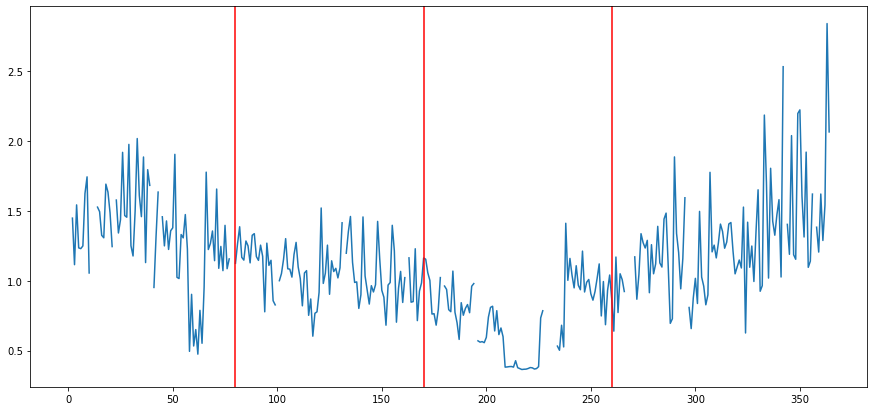

[0.8501749999999991, nan, 1.4468430555555545, 1.1139805555555577, 1.5415138888888908, 1.2341527777777768, 1.2287791666666663, 1.2480611111111117, 1.6228472222222246, 1.7419902777777767, 1.0546416666666674, nan, nan, nan, 1.525527777777778, 1.4931333333333343, 1.323997222222224, 1.3063180555555567, 1.6899361111111084, 1.6331444444444454, 1.4846222222222214, 1.2434902777777788, nan, 1.5759861111111146, 1.3406319444444432, 1.4358083333333331, 1.9172930555555563, 1.465440277777777, 1.4534652777777777, 1.974116666666667, 1.2494416666666681, 1.1762347222222223, 1.4982166666666674, 2.015981944444442, 1.608520833333333, 1.4575638888888887, 1.8840180555555568, 1.1289638888888878, 1.793220833333334, 1.6812027777777754, nan, 0.9512277777777786, 1.3145819444444455, 1.6330249999999973, nan, 1.4563416666666673, 1.2484416666666638, 1.4267777777777793, 1.2230250000000018, 1.3566472222222226, 1.3775888888888903, 1.9029958333333357, 1.0236361111111094, 1.014777777777779, 1.3293597222222227, 1.3056972222

In [183]:
daily_c = plot_daily_consumption(df_hp)
print(daily_c)